In [4]:
from sympy import symbols
from sympy.physics.mechanics import *

q1, q2 = dynamicsymbols('q1 q2')
q1d, q2d = dynamicsymbols('q1 q2', 1)
u1, u2 = dynamicsymbols('u1 u2')
u1d, u2d = dynamicsymbols('u1 u2', 1)
l, m, g = symbols('l m g')

N = ReferenceFrame('N')
A = N.orientnew('A', 'Axis', [q1, N.z])
B = N.orientnew('B', 'Axis', [q2, N.z])

A.set_ang_vel(N, u1 * N.z)
B.set_ang_vel(N, u2 * N.z)

O = Point('O')
P = O.locatenew('P', l * A.x)
R = P.locatenew('R', l * B.x)

O.set_vel(N, 0)
P.v2pt_theory(O, N, A)
R.v2pt_theory(P, N, B)

ParP = Particle('ParP', P, m)
ParR = Particle('ParR', R, m)

kd = [q1d - u1, q2d - u2]
FL = [(P, m * g * N.x), (R, m * g * N.x)]
BL = [ParP, ParR]

KM = KanesMethod(N, q_ind=[q1, q2], u_ind=[u1, u2], kd_eqs=kd)

(fr, frstar) = KM.kanes_equations(BL, FL)
kdd = KM.kindiffdict()
mm = KM.mass_matrix_full
fo = KM.forcing_full
qudots = mm.inv() * fo
qudots = qudots.subs(kdd)
qudots.simplify()
mechanics_printing()
mprint(qudots)

Matrix([
[                                                                                                                u1],
[                                                                                                                u2],
[   (g*sin(q1 - 2*q2) + 3*g*sin(q1) + l*u1**2*sin(2*q1 - 2*q2) + 2*l*u2**2*sin(q1 - q2))/(l*(cos(2*q1 - 2*q2) - 3))],
[(-2*g*sin(2*q1 - q2) + 2*g*sin(q2) - 4*l*u1**2*sin(q1 - q2) - l*u2**2*sin(2*q1 - 2*q2))/(l*(cos(2*q1 - 2*q2) - 3))]])


In [7]:
from sympy import Matrix

x = Matrix([q1, q2, u1, u2])
xdot = qudots   # already computed

In [8]:
from sympy import lambdify
import numpy as np

In [9]:
params = (l, m, g)

In [10]:
rhs = lambdify(
    (x, params),
    xdot,
    modules='numpy'
)

In [12]:
def ode_rhs(t, y, p):
    return np.array(rhs(y, p), dtype=float).flatten()

Set Numerical Values and initial conditions

In [13]:
l_val = 1.0      # m
m_val = 1.0      # kg
g_val = 9.81     # m/s^2

p = (l_val, m_val, g_val)

y0 = [
    np.pi / 4,   # q1(0)
    np.pi / 2,   # q2(0)
    0.0,         # u1(0)
    0.0          # u2(0)
]

In [14]:
from scipy.integrate import solve_ivp

t_span = (0, 10)
t_eval = np.linspace(*t_span, 2000)

sol = solve_ivp(
    fun=lambda t, y: ode_rhs(t, y, p),
    t_span=t_span,
    y0=y0,
    t_eval=t_eval,
    method='RK45',
    rtol=1e-9,
    atol=1e-9
)

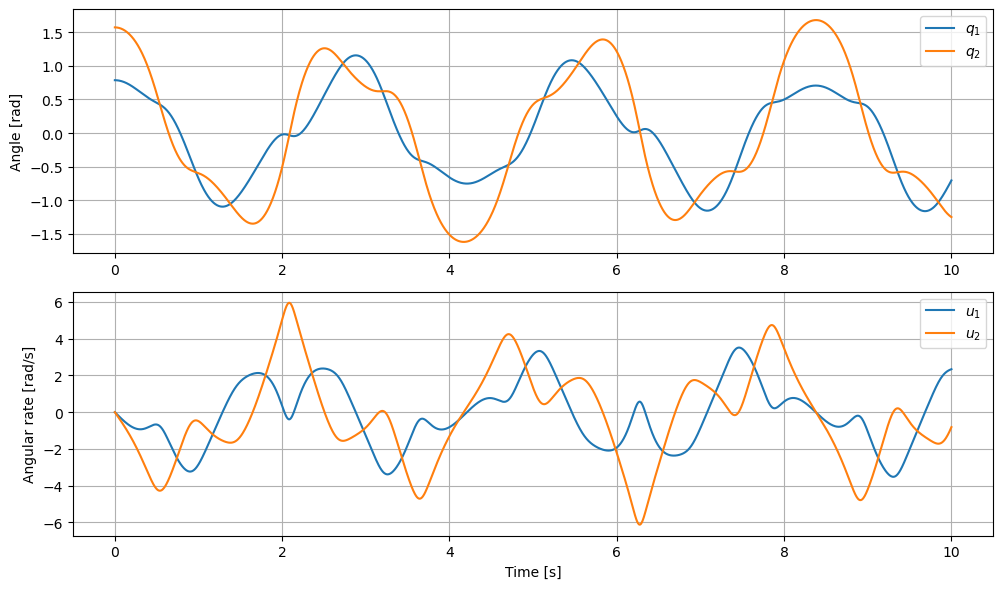

In [15]:
import matplotlib.pyplot as plt

q1_sol = sol.y[0]
q2_sol = sol.y[1]
u1_sol = sol.y[2]
u2_sol = sol.y[3]

plt.figure(figsize=(10, 6))

plt.subplot(2, 1, 1)
plt.plot(sol.t, q1_sol, label=r'$q_1$')
plt.plot(sol.t, q2_sol, label=r'$q_2$')
plt.ylabel('Angle [rad]')
plt.legend()
plt.grid()

plt.subplot(2, 1, 2)
plt.plot(sol.t, u1_sol, label=r'$u_1$')
plt.plot(sol.t, u2_sol, label=r'$u_2$')
plt.ylabel('Angular rate [rad/s]')
plt.xlabel('Time [s]')
plt.legend()
plt.grid()

plt.tight_layout()
plt.show()